# Complete Linear & Polynomial Regression Task – Cancer Mortality Dataset 2020-2024 (US countris)

In [25]:
# importt liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [26]:
df = pd.read_csv("cancer_mortality_valid_model.csv")
df.head()

,FIPSN,NAME,STUSPS,TARGET_deathRate,Asian_Pacific_Islander_Percent,Hispanic_Percent,Black_Percent,Under18_Percent,American_Indian_Alaska_Native_Percent,White_Percent,Age18_39_Percent,Age40_64_Percent,Age65_Over_Percent,Is_Rural,Is_Rural_Binary
0,1053,Escambia,AL,190.0,0.5,2.4,29.4,22.7,2.8,60.0,26.7,31.7,19.0,Rural,1
1,1129,Washington,AL,159.4,0.2,1.0,24.1,20.0,6.7,65.0,24.9,34.1,21.0,Rural,1
2,1113,Russell,AL,205.7,0.6,6.0,45.1,24.3,0.1,43.9,29.2,31.2,15.3,Urban,0
3,1107,Pickens,AL,173.0,0.1,3.6,40.9,19.1,0.3,52.8,27.7,33.3,19.9,Urban,0
4,1119,Sumter,AL,134.9,0.2,0.7,68.1,19.3,0.1,25.7,35.0,25.8,19.8,Rural,1


# EDA

In [27]:
df.shape

(3142, 15)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   FIPSN                                  3142 non-null   int64  
 1   NAME                                   3142 non-null   object 
 2   STUSPS                                 3142 non-null   object 
 3   TARGET_deathRate                       3084 non-null   float64
 4   Asian_Pacific_Islander_Percent         3142 non-null   float64
 5   Hispanic_Percent                       3142 non-null   float64
 6   Black_Percent                          3142 non-null   float64
 7   Under18_Percent                        3142 non-null   float64
 8   American_Indian_Alaska_Native_Percent  3142 non-null   float64
 9   White_Percent                          3142 non-null   float64
 10  Age18_39_Percent                       3142 non-null   float64
 11  Age4

In [29]:
df.describe()

,FIPSN,TARGET_deathRate,Asian_Pacific_Islander_Percent,Hispanic_Percent,Black_Percent,Under18_Percent,American_Indian_Alaska_Native_Percent,White_Percent,Age18_39_Percent,Age40_64_Percent,Age65_Over_Percent,Is_Rural_Binary
count,3142.000000,3084.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000
mean,30383.649268,162.430058,1.550000,10.304583,8.567409,21.766900,1.625048,73.706429,26.336123,31.456906,20.440420,0.622533
std,15162.508374,29.098377,3.182891,13.930017,14.029939,3.647208,7.326254,20.052546,4.909489,2.863546,5.080116,0.484830
min,1001.000000,59.900000,0.000000,0.000000,0.000000,0.000000,0.000000,2.300000,6.100000,12.000000,4.500000,0.000000
25%,18177.500000,144.000000,0.300000,2.700000,0.600000,19.700000,0.100000,61.800000,23.500000,30.100000,17.225000,0.000000
50%,29176.000000,160.800000,0.700000,5.100000,2.100000,21.900000,0.100000,80.300000,25.800000,31.800000,20.000000,1.000000
75%,45080.500000,179.300000,1.500000,11.200000,9.400000,23.700000,0.400000,90.000000,28.400000,33.200000,22.900000,1.000000
max,56045.000000,424.800000,50.700000,97.200000,85.900000,42.100000,90.800000,100.000000,68.700000,45.300000,81.800000,1.000000


In [30]:
df.isnull().sum()

FIPSN                                     0
NAME                                      0
STUSPS                                    0
TARGET_deathRate                         58
Asian_Pacific_Islander_Percent            0
Hispanic_Percent                          0
Black_Percent                             0
Under18_Percent                           0
American_Indian_Alaska_Native_Percent     0
White_Percent                             0
Age18_39_Percent                          0
Age40_64_Percent                          0
Age65_Over_Percent                        0
Is_Rural                                  0
Is_Rural_Binary                           0
dtype: int64

In [31]:
df["TARGET_deathRate"].describe()

count    3084.000000
mean      162.430058
std        29.098377
min        59.900000
25%       144.000000
50%       160.800000
75%       179.300000
max       424.800000
Name: TARGET_deathRate, dtype: float64

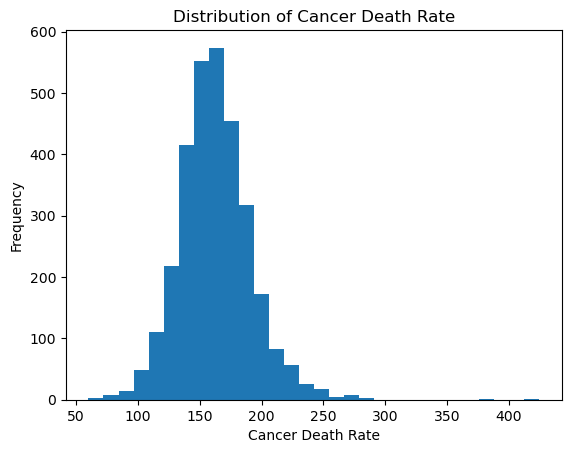

In [32]:
# Target distribution
plt.hist(
    df["TARGET_deathRate"].dropna(),
    bins=30
)

plt.xlabel("Cancer Death Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Cancer Death Rate")

plt.show()

# Correlation

In [33]:
demographic_columns = [

    "Asian_Pacific_Islander_Percent",
    "Hispanic_Percent",
    "Black_Percent",
    "Under18_Percent",
    "American_Indian_Alaska_Native_Percent",
    "White_Percent",
    "Age18_39_Percent",
    "Age40_Over_Percent",
    "Age40_64_Percent",
    "Age50_Over_Percent",
    "Age65_Over_Percent",
    "Male_Percent",
    "Female_Percent"
]

In [34]:
# Correlation with cancer mortality
available_demographic_columns = [
    column for column in demographic_columns
    if column in df.columns
]

correlation_data = df[
    available_demographic_columns + ["TARGET_deathRate"]
]

correlation_data.corr()["TARGET_deathRate"].sort_values(
    ascending=False
)

TARGET_deathRate                         1.000000
Black_Percent                            0.179024
Under18_Percent                          0.142621
American_Indian_Alaska_Native_Percent    0.101964
Age40_64_Percent                         0.049247
White_Percent                            0.032522
Age65_Over_Percent                      -0.057068
Age18_39_Percent                        -0.073886
Hispanic_Percent                        -0.215188
Asian_Pacific_Islander_Percent          -0.284968
Name: TARGET_deathRate, dtype: float64

# Feature Selection

In [35]:
features = [
    "Asian_Pacific_Islander_Percent",
    "Hispanic_Percent",
    "Black_Percent",
    "Under18_Percent",
    "American_Indian_Alaska_Native_Percent",
    "White_Percent",
    "Age18_39_Percent",
    "Age40_64_Percent",
    "Age65_Over_Percent",
    "Is_Rural_Binary"
]

X = df[features]

In [36]:
X = df[features].copy()

y = df["TARGET_deathRate"].copy()

# Missing Values

In [37]:
# Convert to numeric
X = X.apply(pd.to_numeric,errors="coerce")

y = pd.to_numeric(y,errors="coerce")

In [38]:
# Remove rows with missing target
valid_rows = y.notna()

X = X.loc[valid_rows]

y = y.loc[valid_rows]

In [39]:
# Fill missing feature values
X = X.fillna(X.mean())

# Train-Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Data =", X_train.shape)

print("Testing Data =", X_test.shape)

Training Data = (2467, 10)
Testing Data = (617, 10)


# Linear Regression

In [41]:
# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit( X_train, y_train)

# Prediction
y_pred_linear = linear_model.predict(X_test)

# Linear Regression Evaluation
# MAE
mae_linear = mean_absolute_error(y_test,y_pred_linear)
print("mae_linear:",mae_linear )

# MSE
mse_linear = mean_squared_error(y_test,y_pred_linear)
print("mse_linear:",mse_linear)

# RMSE
rmse_linear = np.sqrt(mse_linear)
print("rmse_linear:",rmse_linear)

# R² Score
r2_linear = r2_score(y_test,y_pred_linear)
print("r2_linear:",r2_linear)



mae_linear: 18.352252599002803
mse_linear: 570.6567594900845
rmse_linear: 23.888423126905728
r2_linear: 0.20882719669149374


# Polynomial Regression Degree 2

In [42]:
# Create polynomial features
poly2 = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)

X_test_poly2 = poly2.transform(X_test)

In [43]:
# Create model
poly_model2 = LinearRegression()

# Train Model
poly_model2.fit(X_train_poly2,y_train)

# Prediction
y_pred_poly2 = poly_model2.predict(X_test_poly2)

# Evaluation
mae_poly2 = mean_absolute_error(y_test,y_pred_poly2)
print("MAE =", mae_poly2)

mse_poly2 = mean_squared_error(y_test,y_pred_poly2)
print("MSE =", mse_poly2)

rmse_poly2 = np.sqrt(mse_poly2)
print("rmse =", rmse_poly2)

r2_poly2 = r2_score(y_test,y_pred_poly2)
print("R2 Score =", r2_poly2)

MAE = 17.625614422276673
MSE = 540.4785630064817
rmse = 23.2481948332872
R2 Score = 0.2506670030438475


# Polynomial Regression Degree 3

In [44]:
# Polynomial Regression Degree 3
poly3 = PolynomialFeatures(degree=3,include_bias=False)

X_train_poly3 = poly3.fit_transform(X_train)

X_test_poly3 = poly3.transform(X_test)

# Create model
poly_model3 = LinearRegression()

# Train model
poly_model3.fit(X_train_poly3,y_train)

# Prediction
y_pred_poly3 = poly_model3.predict(X_test_poly3)

# Evaluation
mae_poly3 = mean_absolute_error(y_test,y_pred_poly3)
print("MAE =", mae_poly3)

mse_poly3 = mean_squared_error(y_test,y_pred_poly3)
print("MSE =", mse_poly3)


rmse_poly3 = np.sqrt(mse_poly3)

print("RMSE =", rmse_poly3)


r2_poly3 = r2_score(y_test,y_pred_poly3)
print("R2 Score =", r2_poly3)


MAE = 18.450405789812756
MSE = 783.4160290502689
RMSE = 27.989570004740497
R2 Score = -0.08614757567116693


# Compare Models

In [45]:
# Comparison table
result = pd.DataFrame({

    "Model": ["Linear Regression","Polynomial Degree 2","Polynomial Degree 3"],

    "MAE": [mae_linear,mae_poly2,mae_poly3],

    "MSE": [mse_linear,mse_poly2,mse_poly3],

    "RMSE": [rmse_linear,rmse_poly2,rmse_poly3],

    "R2 Score": [ r2_linear, r2_poly2, r2_poly3]})
result

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,18.352253,570.656759,23.888423,0.208827
1,Polynomial Degree 2,17.625614,540.478563,23.248195,0.250667
2,Polynomial Degree 3,18.450406,783.416029,27.989570,-0.086148


Polynomial Regression achieved the best performance with an R² of approximately 25%, outperforming Linear Regression. However, the overall predictive performance remains low, indicating that demographic variables alone are insufficient for highly accurate cancer mortality prediction.

# Actual vs Predicted

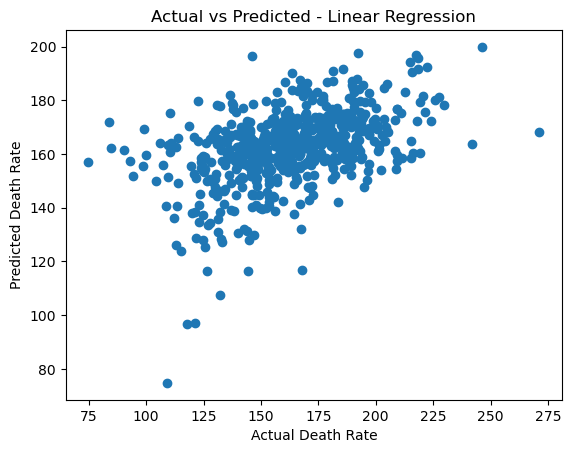

In [46]:
# Linear Regression
plt.scatter( y_test, y_pred_linear)

plt.xlabel("Actual Death Rate")

plt.ylabel("Predicted Death Rate")

plt.title("Actual vs Predicted - Linear Regression")

plt.show()

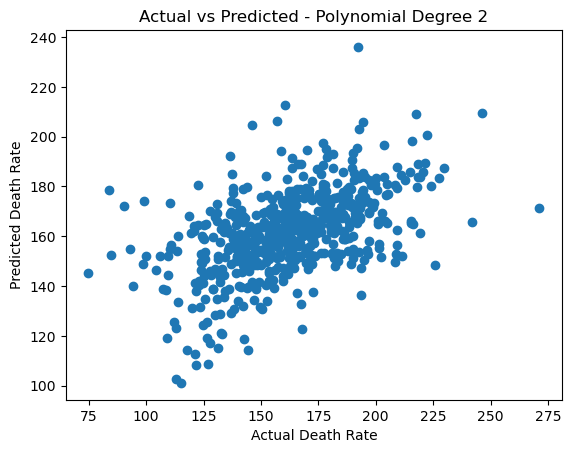

In [47]:
# Polynomial Degree 2
plt.scatter(y_test,y_pred_poly2)

plt.xlabel("Actual Death Rate")

plt.ylabel("Predicted Death Rate")

plt.title("Actual vs Predicted - Polynomial Degree 2")

plt.show()

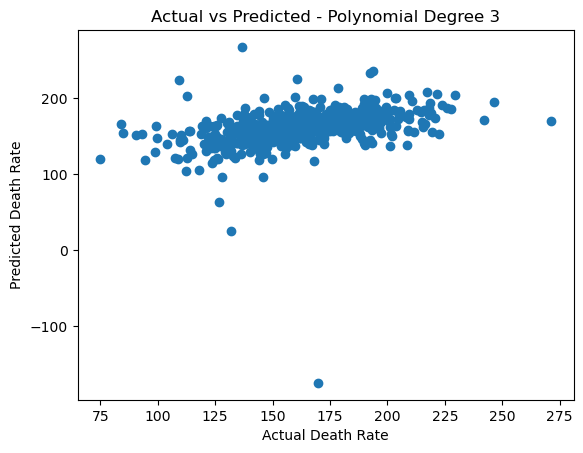

In [48]:
# Polynomial Degree 3
plt.scatter(y_test,y_pred_poly3)

plt.xlabel("Actual Death Rate")

plt.ylabel("Predicted Death Rate")

plt.title("Actual vs Predicted - Polynomial Degree 3")

plt.show()

# Residual Plot

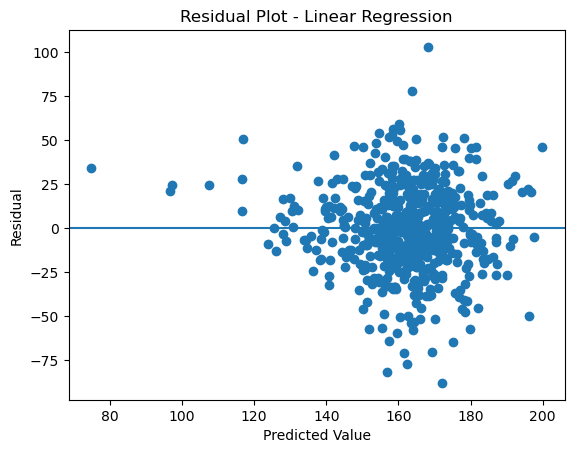

In [49]:
# Linear Regression residual
residual = (y_test - y_pred_linear)

plt.scatter(y_pred_linear,residual)

plt.axhline( y=0)

plt.xlabel("Predicted Value")

plt.ylabel("Residual")

plt.title("Residual Plot - Linear Regression")

plt.show()

